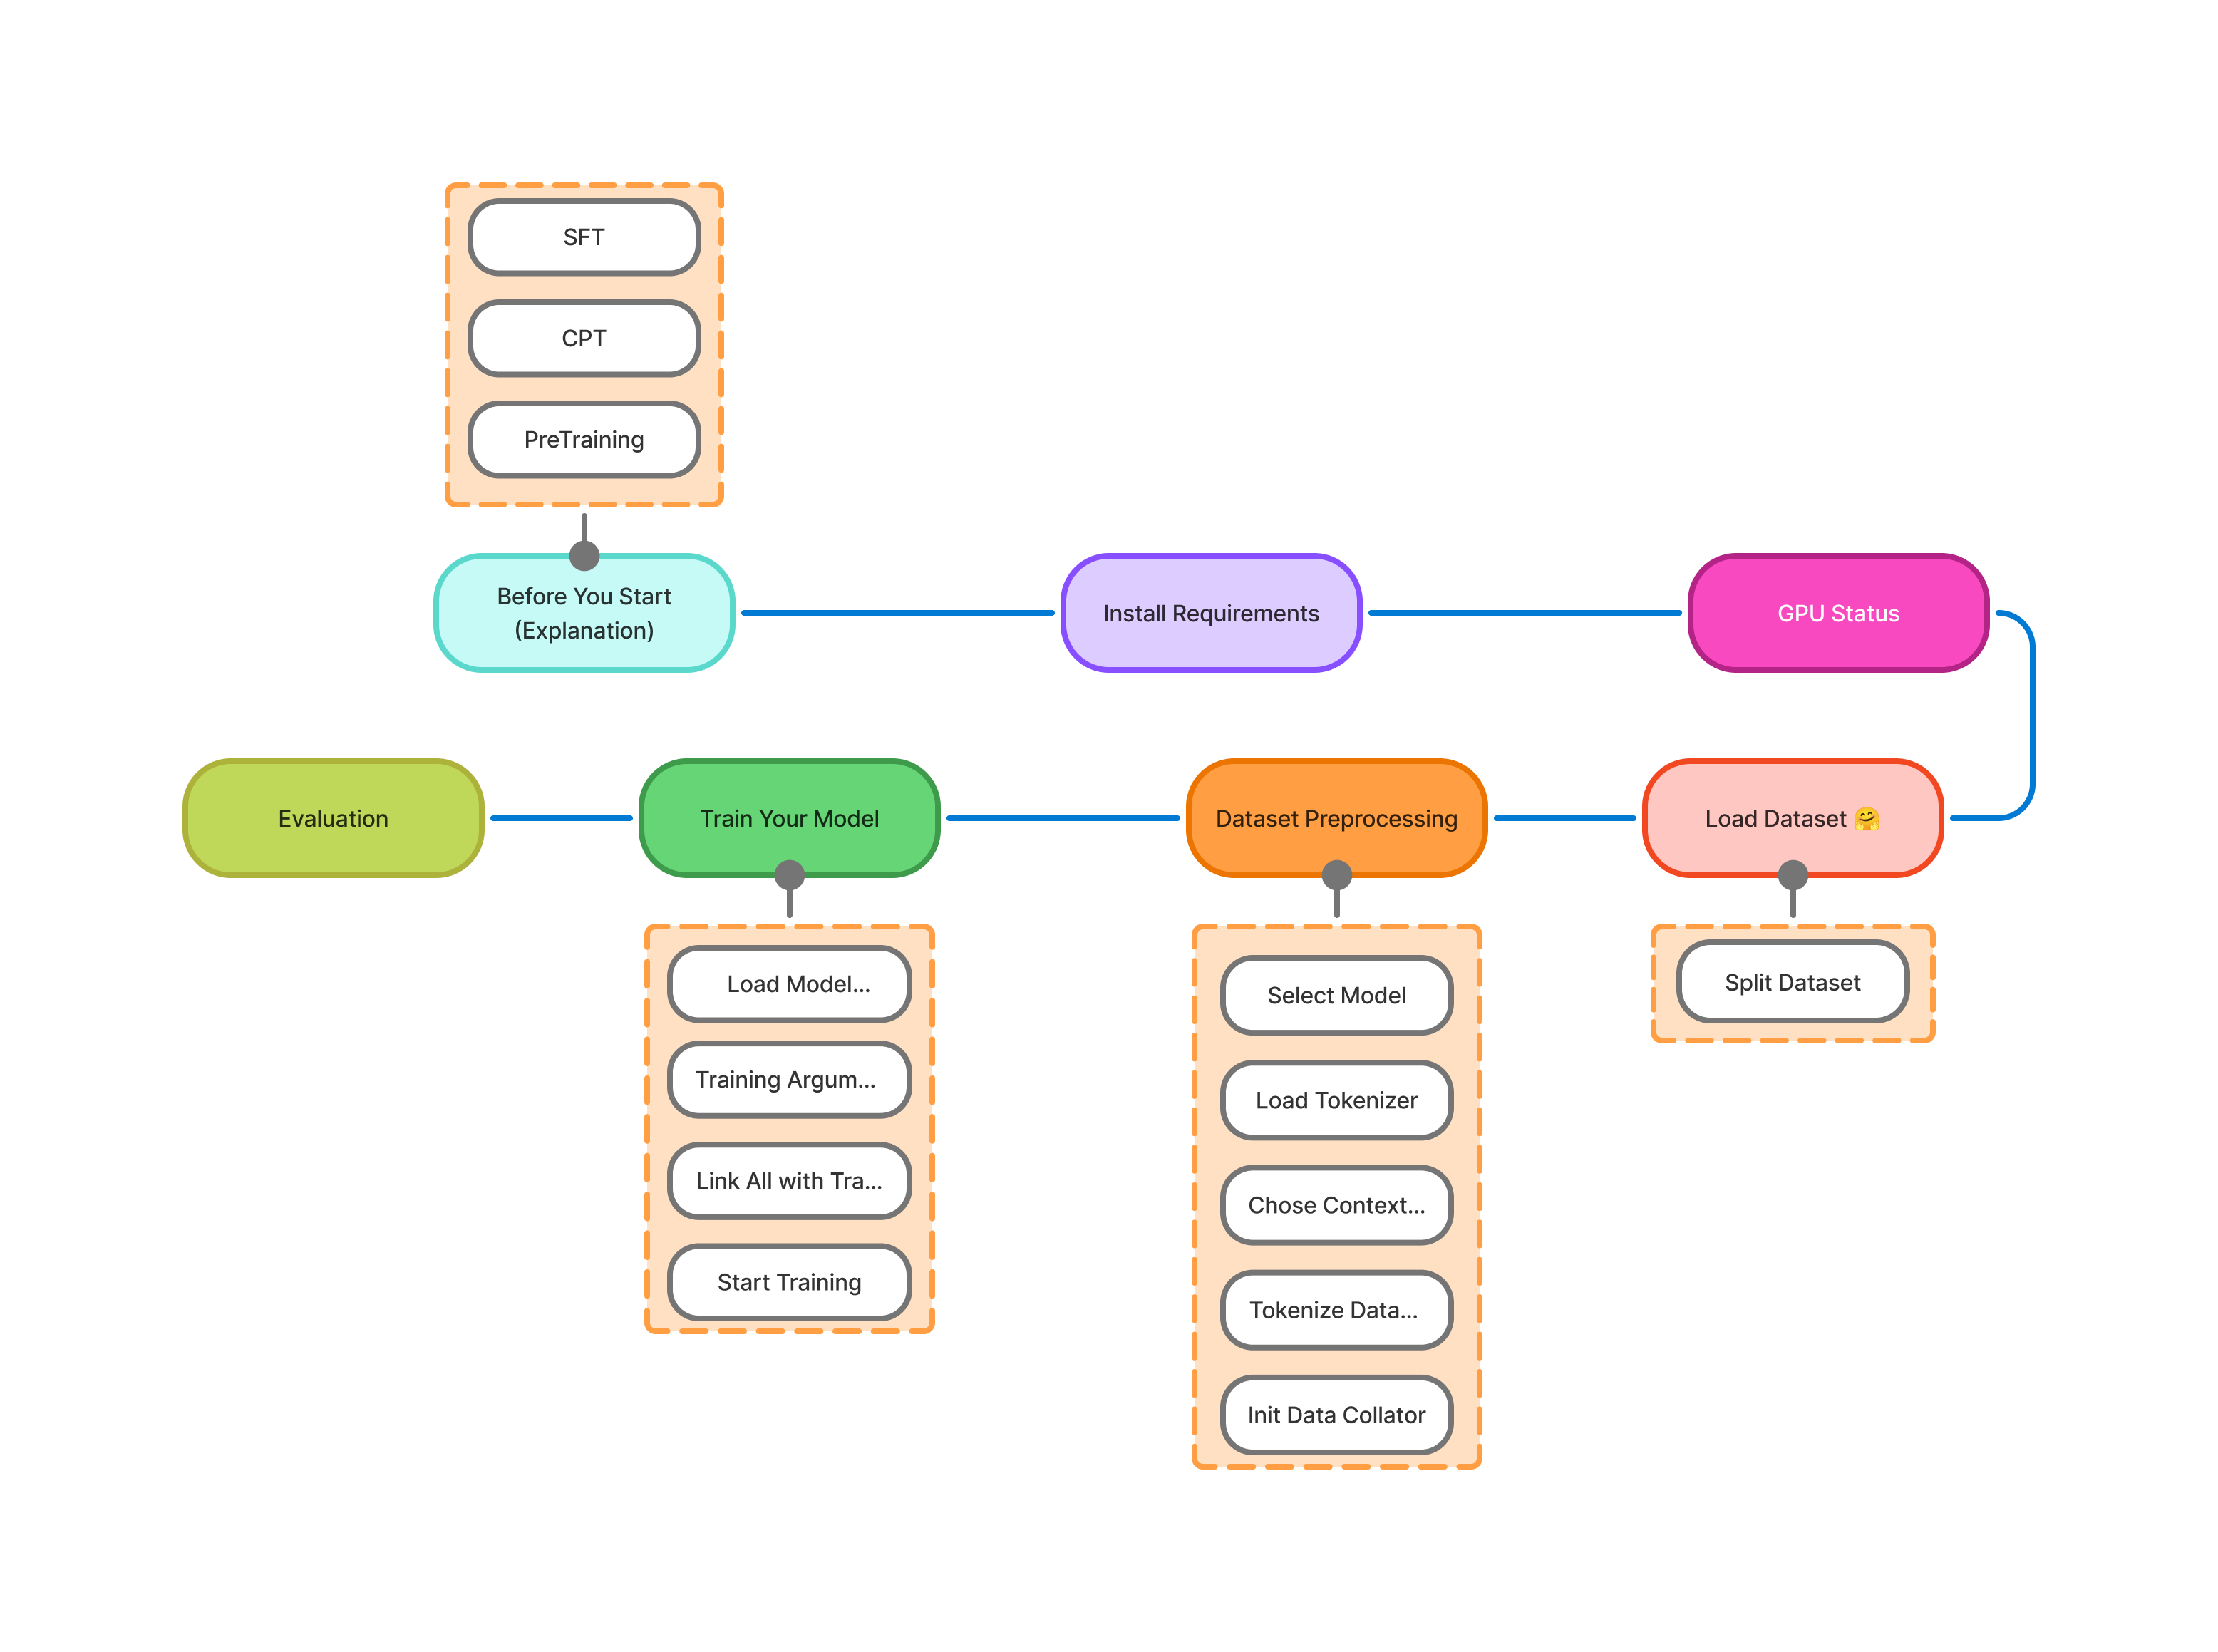

# Before You Star

* **What is Regular Pretraining (RPT)?**

> The first step in creating a high-quality LLM is to pretrain it on one or more massive text datasets. During training, it attempts to **predict the next token** to accurately learn **linguistic** and **semantic** representations found in the text.
this is called language modeling and is a **self-supervised** method.

<center>

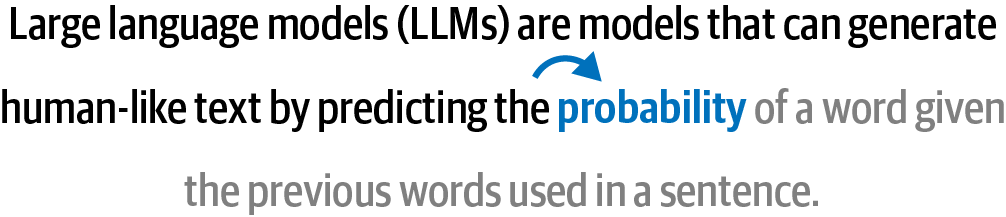

</center>

> The purpose of pretraining a model on large datasets is that it is **able to reproduce language and its meaning**. During this process, the model learns to complete input phrases.

> The pretraining stage produce to us **base model** and also called **foundation model**.



```
🤗 huggingface Base models examples:

- HuggingFaceTB/SmolLM2-135M
- Qwen/Qwen2.5-0.5B
- meta-llama/Llama-3.3-70B
- mistralai/Mistral-7B-v0.3
```



* **Continued Pretraining (CPT)**

>Continued or continual pretraining (CPT) is necessary to “steer” the language model to **understand new domains of knowledge**, or **out of distribution domains**. Base models like Llama-3 or Qwen are **first pretrained on gigantic datasets of trillions of tokens** (Llama-3 for eg is 15 trillion). But sometimes these models have **not been well trained on other languages (eg arabic, darija)**, or text specific domains, like **law, medicine or other areas**.

<center>

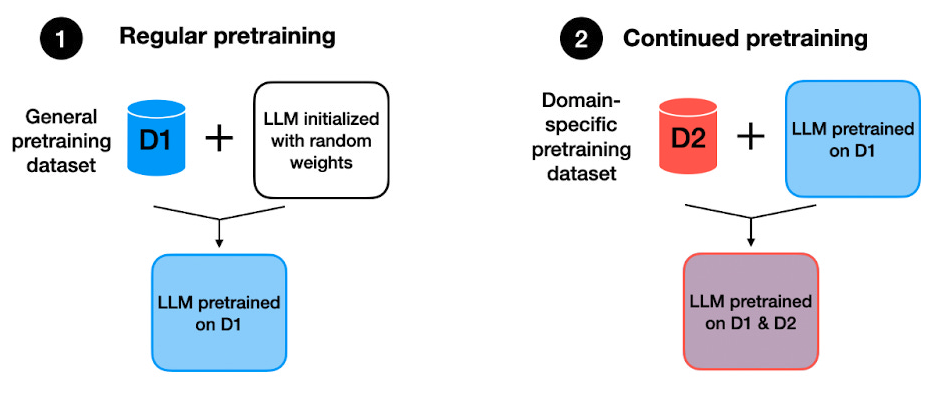

</center>


> Continued pretraining (CPT) is necessary to make the language model learn new tokens or datasets.

* **What is Finetuning (SFT)?**

> In this stage after we got our base model that's understand the languge, with **supervised finetuning (SFT**) we can adapt the base model ***to follow instructions***.

> During SFT process the model parameters are **updated** to be more in line with out target task (eg Q/A.)


<center>

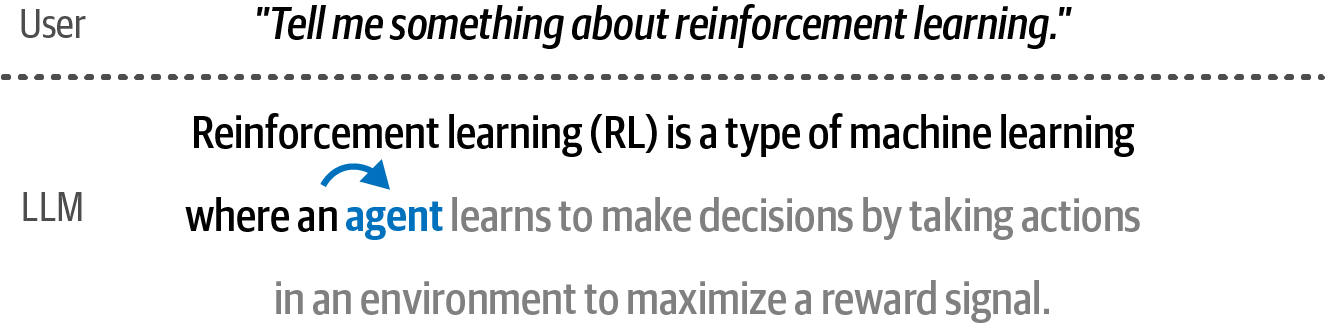
</center>

> SFT training is like pretraining (trained using next-token prediction); the only difference is that SFT is **based on user input**.

> After SFT of our base model we will get new model that's called **Instruction Model**

```
🤗 huggingface Instruct models examples:

- HuggingFaceTB/SmolLM2-135M-Instruct
- Qwen/Qwen2.5-0.5B-Instruct
- meta-llama/Llama-3.3-70B-Instruct
- mistralai/Mistral-7B-Instruct-v0.3

```

<center>

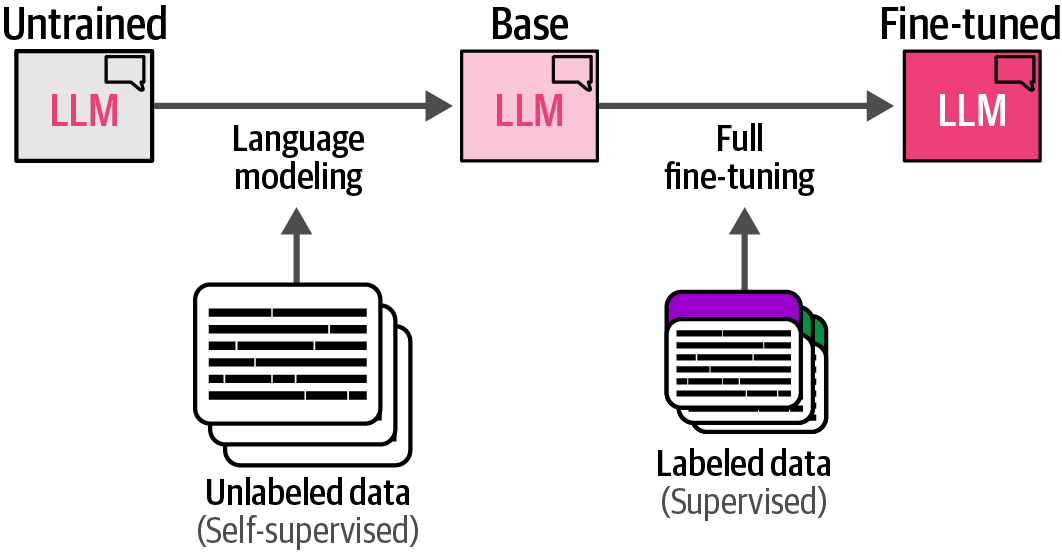

</center>


> In the stage of pretraining your model you need a huge amount of unlabeled data (text)

> In the finetuning stage you need labeled data (also called instruction dataset )

# Install Requirements

In [ ]:
! uv pip install -U datasets -q

In [ ]:
# restart the kernel
exit()

# Check GPU Memory

In [ ]:
import torch
torch.cuda.is_available() # True means you're using nvidia gpu

True

In [ ]:
! nvidia-smi # you can also use nvitop "pip install nvitop" to see real time gpu consumption in your terminal

Fri May 15 00:12:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Load Your Dataset

> In this section we will learn how to load our dataset from huggingface 🤗, select the column we want to train our model on, finallu split it to train/test.


1. huggingface loging

In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


2. load dataset using `load_dataset`and the id of dataset from huggingface `username\datasetname` example `atlasia\atlaset`

In [ ]:
from datasets import load_dataset, Dataset
import pandas as pd

In [ ]:
dataset_name_id="atlasia/Social_Media_Darija_DS"
ds=load_dataset(dataset_name_id,split="train",name="default")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/train-00000-of-00001.parquet:   0%|          | 0.00/3.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10742 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'lang', 'source', '__index_level_0__'],
    num_rows: 10742
})

In [ ]:
# select only the text columns (eg content) that's our model want to train on.
ds=ds.select_columns(["text"])
ds

Dataset({
    features: ['text'],
    num_rows: 10742
})

In [ ]:
# take a look in our dataset using pandas
ds.to_pandas().head()

,text
0,الحلقة رقم 63# من البودكاست.\n\nفهاد الحلقة من...
1,الحلقة رقم 62# من البودكاست.\n\nفهاد الحلقة من...
2,الحلقة رقم 61# من البودكاست.\n\nفهاد الحلقة من...
3,خصّ تعرفو بلّي فن تجلايجيت فالمغرب معروف بواحد...
4,من كنّاش الڭانة و الكسدة...


3. split our dataset into train and test

In [ ]:
ds_spliter=ds.train_test_split(test_size=0.2,seed=42)
ds_spliter

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 8593
    })
    test: Dataset({
        features: ['text'],
        num_rows: 2149
    })
})

# Preprocessing For Pretraining LM

> In this step we will go through the necessary preprocessing steps befor starting train.

1. select the base model you want to train from hf 🤗


In [ ]:
model_id="HuggingFaceTB/SmolLM2-135M-Instruct" # example HuggingFaceTB/SmolLM2-135M-Instruct

2. load model tokenizer

In [ ]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained(model_id)

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

3. check some tokenizer configs

In [ ]:
# check the vocabe size of our tokenizer
print(f"{len(tokenizer)}")
# model max length (means the max len of the input)
print(f"{tokenizer.model_max_length}")
# tokenizer special tokens
print(tokenizer.special_tokens_map)

49152
8192
{'bos_token': '<|im_start|>', 'eos_token': '<|im_end|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|im_end|>'}


4. test tokenizer

<center>

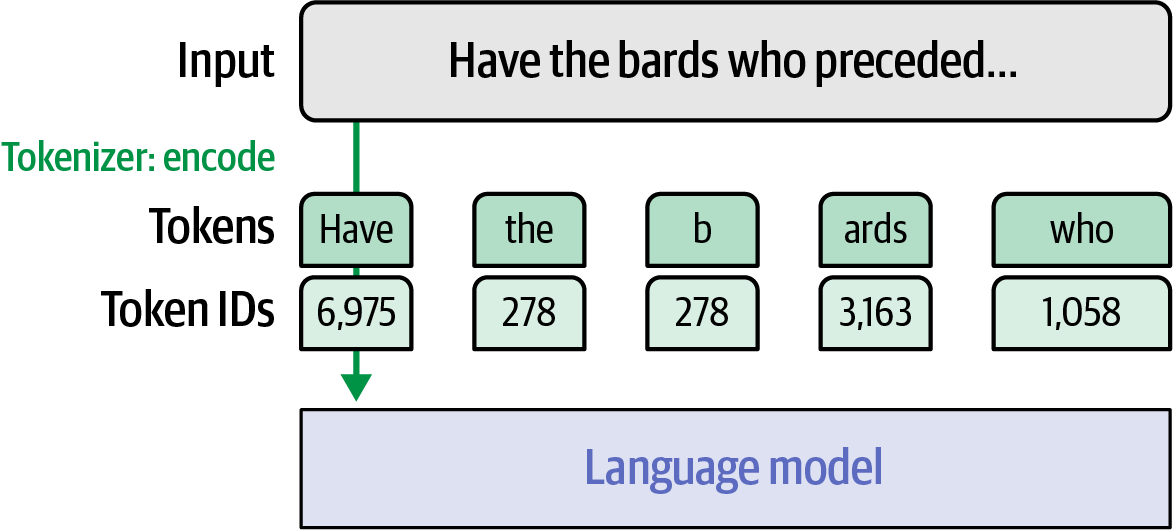

</center>

In [ ]:
example="Hello my name x I'm ThinkAI participant"
ids=tokenizer.encode(example)
print(ids)
tokens=tokenizer.convert_ids_to_tokens(ids)
print(tokens)
decode_=tokenizer.decode(ids)
print(decode_)

[19556, 957, 1462, 1792, 339, 5248, 6545, 13701, 15634]
['Hello', 'Ġmy', 'Ġname', 'Ġx', 'ĠI', "'m", 'ĠThink', 'AI', 'Ġparticipant']
Hello my name x I'm ThinkAI participant


> After learned about Tokenizer, now we will go through encode our input text. the only things we need to fix is the `context length`and it should be less than or equal the `model_max_length`.
* Big `context length` means more context
* More `context length` more GPU memory
* `contenxt length` Recommended to be in **%64** `[64,128,256,...max_length]` to train you model faster try to use 128.
* all input ids will **turncated** to be in selected `context length`

<center>

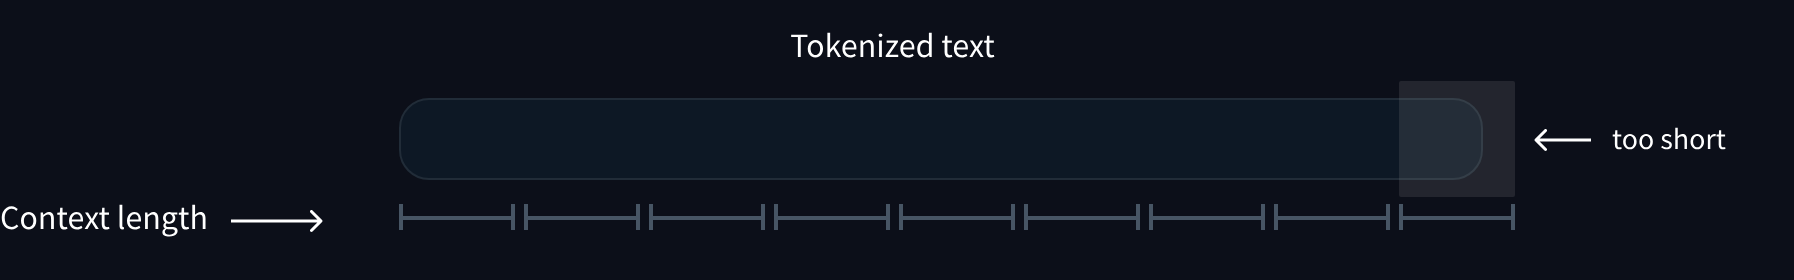
</center>

In [ ]:
# الطاوسي قال لـ "الصباح الرياضي" إن مسؤولي "الماص" استغلوا سذاجته و "كلاوه فرزق وليداتو" أبدى رشيد الطاوسي، مدرب الرجاء الرياضي، افتخاره بتدريب الثلاثي القوي لكرة القدم الوطنية المتمثل في فريقه الحالي والوداد الرياضي والجيش الملكي . وكشف الطاوسي أن هذه الثقة نابعة من قدرته على التأقلم مع جميع الأجواء وتفانيه في أداء مهامه، وبصم طريقة لعبه أينما حل وارتحل. وعاد الطاوسي في حوار أجراه معه "الصباح الرياضي" للحديث عن الضجة التي أثارها مسؤولو "الماص" بعد تعاقده مع الرجاء، واعتبرها مفتعلة، الغاية منها دفعه إلى التنازل عن مستحقاته المالية العالقة، وهو ما نجحوا فيه إلى أبعد حد حسب رأيه، مستغلين سذاجته في التعامل مع الوضع. وأبرز المدرب السابق للمنتخب الوطني ومجموعة من الأندية الوطنية، آخرها المغرب الفاسي، أنه قادر على إعادة الطابع الفرجوي لأداء الرجاء مع النجاعة في النتائج وتحقيق الألقاب، شريطة الدعم والمساندة من جميع فعاليات الفريق، في مقدمتها الجمهور، الذي اعتبره الطاوسي المدعم رقم واحد لمجموعته. واعتبر الطاوسي "دقة دقة وحكان الجلدة" شعارا للمرحلة، خصوصا أن جل لاعبي الرجاء يتوفرون على مهارات تقنية وبدنية لتحقيق ازدواجية الفرجة والنتائج، التي غابت عن الفريق، بسبب التغييرات التي طرأت على الطاقم التقني في الفترة الأخيرة. وفي ما يلي نص الحوار: تعتبر من المدربين المحظوظين الذين أشرفوا على الثلاثي الرجاء والوداد والجيش، بماذا تفسر هذا الموضوع؟ أكيد أن تدريب هذا الثلاثي، بمثابة الإشراف على المنتخب، وأنا سعيد بالثقة التي وضعها مسؤولو هذه الفرق العملاقة في شخصي، وهذا إن دل على شيء إنما يدل على إيمانهم بإمكانياتي، وقدرتي على التأقلم مع الأجواء، وبصم طريقة لعبي وإعطاء طابعي الخاص للأندية التي أشرفت على تدريبها، وأنا فخور بالمكانة التي بت أحظى بها داخل المنظومة الكروية الوطنية، وسأبذل قصارى جهدي لأنجح رفقة الرجاء ومواصلة المسيرة. كيف تم الاتصال بينك وبين الرجاء؟ بشكل عاد وطبيعي، عكس ما روج له الكثيرون، فأنا لم أعرض خدماتي وأنا على ذمة فريق آخر، بل إن الاتصال تم بعد انفصالي عن "الماص"، وإقالة كرول من تدريب الرجاء، وبطبيعة الحال لم يكن بإمكاني رفض عرض من فريق بمرجعية الرجاء، الذي كنت دائما أتمنى أن تتاح لي الفرصة لتدريبه. الحلم كاد يتبخر بعد أن دخل "الماص" على الخط وتشبث بك مدربا… (مقاطعا) مجرد مناورة الغاية منها دفعي إلى التنازل عن مستحقاتي المالية العالقة، وأعتقد أن مسؤولي هذا الفريق العريق نجحوا في مهامهم، ودفعوني إلى التنازل عن حقوقي مقابل نيل راحة البال، والتفرغ إلى مهامي الجديدة، وأتمنى فقط أن يستثمروا تلك الأموال في ما هو إيجابي ويصرفوا للاعبين رواتبهم ومستحقاتهم، السبب الحقيقي وراء مغادرة "الماص". كان بإمكانك اللجوء إلى السبل القانونية لاستخلاص مستحقاتك… بالفعل كان حلا من الحلول، لكنني فضلت إنهاء كل مشاكلي قبل الشروع في مهامي الجديدة، التي تقتضي تفرغا تاما، بعيدا عن لجنة النزاعات والمحاكم. مسؤولو "الماص" بمساومتهم هاته "كلاوني في رزق ولادي، وأنا مسامح ليهم على وجه جمهور "الماص" والمدينة اللي قضيت فيها أسعد لحظات مسيرتي التدريبية". لكن يجب الاعتراف أنه كانت أخطاء في مسطرة فسخ العقد… لم تكن هناك أخطاء، بل تدابير إدارية كان يجب اتباعها. للأسف مسؤولو "الماص" استغلوا سذاجتي وطعنوني من الخلف ونالوا ما كانوا يصبون إليه، على كل حال هذا ملف طوي نهائيا ولا أريد الخوض فيه كثيرا، وأسعى من خلال تعاقدي مع الرجاء لإعطاء انطلاقة جديدة لمسيرتي التدريبية، والبحث عن الألقاب التي خاصمتني منذ مدة طويلة. ما هي الأهداف المسطرة مع مكتب الرجاء؟ ليست هناك أهداف مسطرة مع الأندية الكبيرة، ولا يمكن التعاقد مع فريق بقيمة الرجاء لتكوين فريق، فالمهمة ظاهرة للعيان، ولا محيد عنها والمتمثلة في التنافس على الألقاب وإغناء خزانة الفريق، وعكس ما يعتقده الكثيرون فالرجاء مازال في السباق للظفر بلقب البطولة، ولعب نصف نهائي كأس العرش، وخرج منه بشرف على يد حامل اللقب، وبالتالي فإن كل المعطيات متوفرة لمواصلة المسيرة، مع إجراء بعض "الرتوشات" الضرورية بعد دخول أي مرحلة جديدة. أكيد أنك كنت تتابع الرجاء ولديك فكرة على تركيبته البشرية… لا يجادل اثنان في أن الرجاء يتوفر على أقوى تركيبة بشرية في البطولة، بل إنه يشكل منتخبا قائم الذات، وأي مدرب لا يمكنه سوى أن يكون سعيدا بالتوفر على أسماء كتلك التي تدافع عن ألوان الفريق هذا الموسم، وسأحاول خلق الانسجام الذي كان غائبا لبناء فريق قوي ومتجانس وتنافسي، وهذا لا يمكنه أن يحدث سوى بتضافر جل الفعاليات، خصوصا الجمهور الذي يعد السند الرئيسي للفريق، وقوته الضاربة. عقدت بعض اللقاءات مع اللاعبين، ماذا لمست فيهم؟ أولا أشكرهم على حسن الاستقبال، ما ظهر جليا في طريقة تعاملهم مع التعليمات الجديدة، والأكيد أنهم في حاجة إلى عمل كبير على المستوى الذهني، خصوصا بعد مغادرة منافسة كأس العرش من دور متقدم، وهذا ما سأحاول القيام به في المرحلة المقبلة، لأن لاعبي الرجاء ليسوا في حاجة لمن يلقنهم أبجديات اللعبة، بل هم في حاجة لمن يدعمهم فكريا ونفسيا في هذه المرحلة، وهذا دوري ودور الجمهور الذي دأب على مساندتهم في أحلك اللحظات. لم تحدث تغييرات على الطاقم التقني، باستثناء استقدام مدرب مساعد بعد استقالة القرقوري… لم أبحث عن إحداث القطيعة مع الماضي من خلال إجراء تغييرات شاملة، بل إن هاجسي كان الاستفادة من خبرة ومعلومات عناصر كانت حاضرة في المرحلة السابقة، وهذا سيفيدني كثيرا في التعامل مع المجموعة، فقط كنت مضطرا لاستقدام مساعد بعد استقالة القرقوري. وماذا عن الخياطي مدربا مساعدا؟ أولا للتنوير الخياطي ليس مدربا مساعدا، بل مدرب ثان، بإمكانه تقديم الإضافة، لخبرته الطويلة في مجال التدريب، وللتجانس الحاصل بيني وبينه على جل المستويات. لقد بحثت عن الشخص الذي بإمكانه المناقشة وإبداء الرأي مهما كان مخالفا لما فيه مصلحة الرجاء. انتظر الشيء الكثير من الخياطي الذي أكن له كل الاحترام، وواثق من نجاحه في تجربته الجديدة. هل ستحدث تغييرات على النهج التكتيكي للرجاء؟ هذا مطلوب مني بطبيعة الحال، لأن مسؤولي الفريق تعاقدوا معي من أجل ذلك، ومتأكدون من أن أسلوبي في اللعب يوافق كثيرا مدرسة الرجاء التي تعتمد الفرجة والأداء داخل رقعة الميدان، دون نسيان النتيجة. سأنتظر عودة بعض المصابين، لتكتمل الصورة. سجلت بعض الملاحظات في مباراة الحسيمة، وسأعمل على إصلاحها بداية بإعادة ياسين الصالحي إلى مكانه الطبيعي بوسط الميدان، حيث يبدع ويقدم الإضافة، ثم سأنتظر عودة الحافيظي والقديوي لتوظيفهما بشكل إيجابي داخل المجموعة، في انتظار التعاقد مع هداف في فترة الانتقالات الشتوية، لتكتمل السمفونية. هل ستقوم بانتدابات في فترة الانتقالات الشتوية؟ حسب حاجيات الفريق، أكيد أنها لن تكون كثيرة، لكنها ستهم على الخصوص خط الهجوم. سنناقش المكتب المسير في الموضوع، وسنضع "بروفيل" للاعبين القادرين على تقديم الإضافة للمجموعة، غير ذلك لا يمكننا إثقال كاهل ميزانية الفريق بلاعبين يجلسون في كرسي الاحتياط. يراهن عليك الجمهور إلى إعادة الطابع الفرجوي للرجاء… "دقة دقة وحكان الجلدة" شعار المرحلة، مع النجاعة الهجومية بطبيعة الحال، في إطار البحث عن هوية الفريق، التي ميزته عبر التاريخ. الفريق يتوفر على كل وسائل النجاح والعودة إلى الأضواء، ولدي اليقين أنه بتضافر الجهود، والمساندة الجماهيرية المطلقة واللامشروطة، سنعود به إلى الزمن الجميل، زمن الألقاب والعروض الجميلة. هناك من يتحدث عن خلافات سابقة مع أنس الزنيتي… (مقاطعا) أبدا الزنيتي واحد من أبنائي، وتابعت وحضرت مسيرته، وكنت وراء حراسته لعرين الأسود والمحليين، فكيف لي أن أختلف معه. هذا نوع من الإشاعات الذي يحبط العزيمة ويسمم الأجواء. مدة العقد الذي يربطك بالرجاء لن تسمح لك بتحقيق كل أمنياتك… سنة ونصف، حقيقة مدة قصيرة، لكنني واثق في أننا سنحقق خلالها أشياء جميلة، ربما ستفتح شهيتنا نحو التعامل لمدة أطول، لكن المهم في الفترة الحالية هو إعادة الثقة للجمهور، والبحث عن هوية الفريق الضائعة في ظل التغييرات الكثيرة التي طرأت على طاقمه التقني. وهنا أود أن أناشده بالحضور إلى المدرجات، لأن الكثير من الأشياء ستتغير، وإن شاء الله سنكون في مستوى تطلعاته، وسنحيي داخل الرجاء كل شيء جميل تعود عليه، وأؤكد أن تدريب الرجاء رهان حقيقي وتحد بالنسبة إلي، لأنني كنت دائما أشعر أن أسلوبي وقناعاتي في التدريب قريبة من هذا الفريق. أجرى الحوار: نورالدين الكرف في سطور الاسم الكامل: رشيد الطاوسي تاريخ الازدياد: 6 فبراير 1956 بسيدي قاسم الأندية التي أشرف على تدريبها: اتحاد سيدي قاسم والمغرب الفاسي والجيش الملكي والوداد الرياضي واتحاد طنجة والنادي القنيطري مهام أخرى: مدرب لمنتخبات الفتيان والشباب والمحلي والكبار ومدير تقني للشباب والعين الإماراتيين ألقابه: بطولة إفريقيا للشباب 1997 والثلاثية التاريخية رفقة "الماص" حينما أحرز كأس الكنفدرالية الإفريقية وكأس السوبر وكأس العرش بورتريه الأنــيــق بداخل رشيد الطاوسي، المدرب المثير للجدل، بحركاته البهلوانية في دكة الاحتياط، وتصريحاته المثيرة بعد نهاية المواجهات، يختبئ ذلك الشخص الوديع المقبل على الحياة، الرومانسي العاشق للطبيعة والجمال، البشوش المنطلق ومحب المغامرات. الطاوسي الأنيق والحريص على مظهره، صارم إلى حد بعيد وقت اللزوم، وحنون وعاطفي في الكثير من الأحيان. يحب فعل الخير والاندماج في الأعمال الجمعوية. وطني لأبعد الحدود، واثق من إمكانياته رغم الانتقادات. يعشق التحدي وركوب الصعاب. بليغ في الكلام، وقوي في الحوار. ثقافته وإلمامه بالعديد من الأمور في الحياة، يجعلان منه رجلا مثاليا في زمن اندثرت فيه المثالية وحل مكانها كل شيء… لا يمكن أن ننكر على الطاوسي ما قدمه لكرة القدم الوطنية، فهو أول مدرب وطني حاز لقبا قاريا رفقة فئة الشباب، وفتح أمامهم أبواب المونديال، وأول مدرب يقود فريقا وطنيا نحو ثلاثية تاريخية، بعد أن هزم التوانسة في عقر دارهم، وأول مدرب ينتزع شعبية الزاكي، بعد أن تفوق عليه وحظي بشرف تدريب الأسود ولو لفترة وجيزة. الطاوسي الإنسان طموح، ولا حدود لأحلامه، متوازن في حياته، أب حنون وزوج مثالي…منفعل في بعض الأحيان، لكنه لا يتجاوز حدوده … هكذا هو الطاوسي لمن لا يعرفه…يكبر مع كل إنجاز، ويعترف بالفشل حين اللزوم…

4. set context length

In [ ]:
context_length=128

5. tokenize function

> with tokenize function we will tokenize all the text input and truncate it to be in the same `context_length`, and finally we will keep only the input ids with `length == context_lenght`

In [ ]:
def tokenize(examples):
  results=tokenizer(
      examples["text"],
      truncation=True,
      max_length=context_length,
      return_overflowing_tokens=True, # with this you will get also the input ids with length less than context_length
      return_length=True
  )
  input_batch=[]
  for l,in_ids in zip(results["length"],results["input_ids"]):
    if l==context_length:
      input_batch.append(in_ids)
  return {"input_ids":input_batch}

> After creating the tokenize function now we will tokenize all text using `map()` method by datasets. after tokenized you text dataset the number of rows will increase cause of each example will have `context_size`.
* we need only the input_ids column to train our model, that's why we need to remove the others with `remove_columns` attribute.

In [ ]:
tokenized_ds=ds_spliter.map(tokenize,batched=True,remove_columns=ds_spliter["train"].column_names)

Map:   0%|          | 0/8593 [00:00<?, ? examples/s]

Map:   0%|          | 0/2149 [00:00<?, ? examples/s]

> now the last step in data preprocessing is to generate batches and labels using `DataCollatorForLanguageModeling`, the main roles of this function is:

<center>

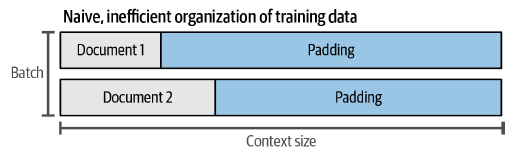
</center>

* Create batches
* Add Padding to batches (Inputs are dynamically padded to the maximum length of a batch if they are not all of the same length.)
* Creating Labels

<center>

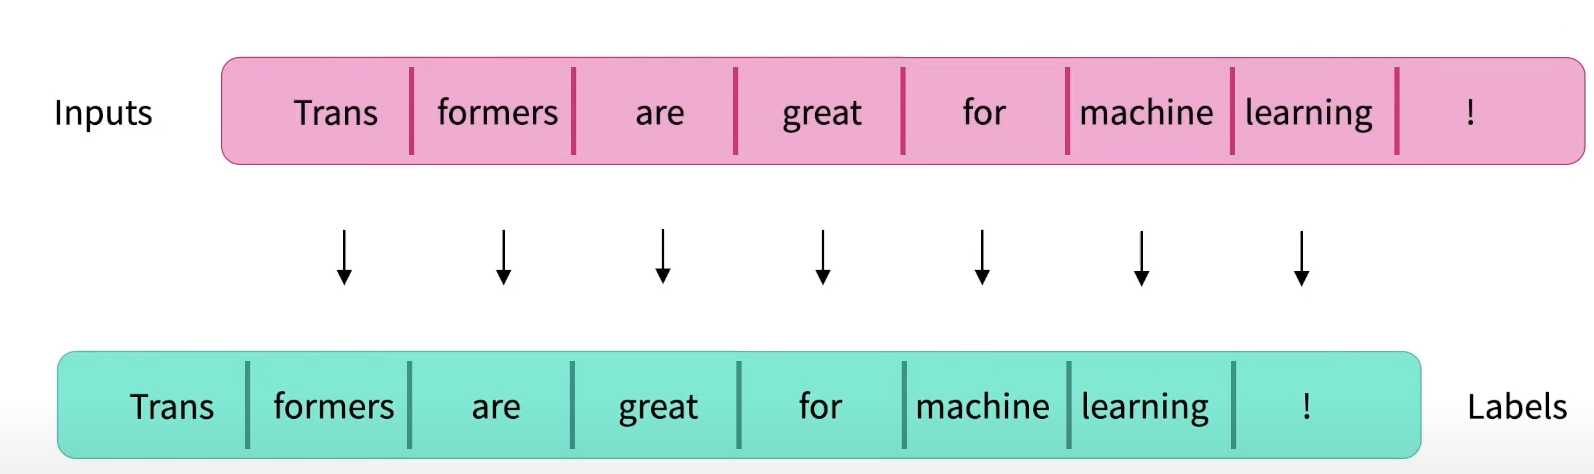

</center>

* Masked % from text when we train Masked Language Model (MLM) models. (in our case `mlm=False`)


In [ ]:
from transformers import DataCollatorForLanguageModeling
data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer,mlm=False)

# Load & Train Your Selected Model

### Load Model

> After preprocessing stage, now we are ready to train our model, but first of all we need to select which method we want to use as explained above [first section].

* training from scratch (RPT)

<center>

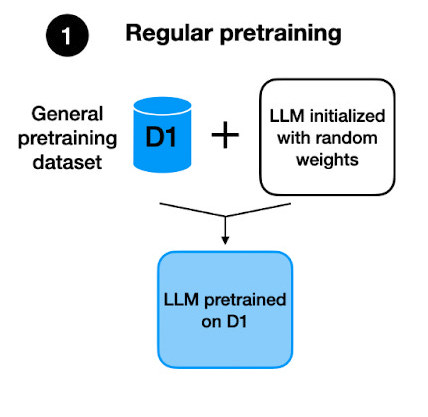
</center>

```
  *  will load model and init weights with random values
  1. load model configs using AutoConfig.form_pretrained
  2. load model architect using AutoModelForCausalLM.from_config
```

* continuos training (CPT)

<center>

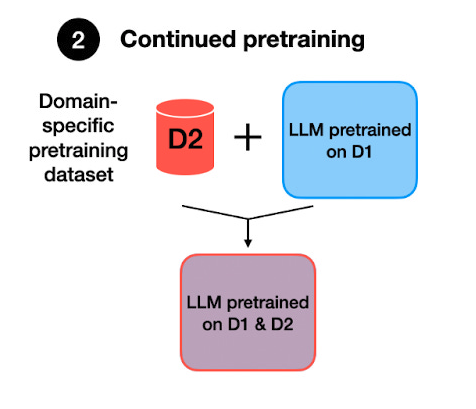
</center>

```
  * will load the model with trained weights
  1. load model  and weights using AutoModelForCausalLM.form_pretrained
```

the difference between those 2 methods is only on loading model code.

In [ ]:
from transformers import AutoModelForCausalLM,AutoConfig
config=AutoConfig.from_pretrained(model_id)
model=AutoModelForCausalLM.from_config(config)

### Train Args

> Now in the last step before training, we should set the training arguments, and the important one is:
* `output_dir` [dir to save the model checkpoints]
* `num_train_epochs`
* `learning_rate`
* `lr_scheduler_type` [linear/cosine]
* `batch_size` [train/eval]
* `warmup_steps` [increase lr from low val to target value during the begining x steps]
* `save_steps` [save every x steps]
* `save_total_limit` [save only x checkpoints to avoid memory space :( ]
* `fp16` [mixed-precision training]
* `push_to_hub` [push the trained model to the hub after finishing]
* `logging_steps` [show logs (loss/accuracy) after x steps]
* `report_to` [we will use wand]
* `...`

In [ ]:
from transformers import TrainingArguments
args=TrainingArguments(
    output_dir="test_dir",
    num_train_epochs=2,
    per_device_eval_batch_size=8,
    per_device_train_batch_size=8,
    learning_rate=5e-4,
    warmup_steps=100,
    lr_scheduler_type="linear",
    save_steps=100,
    save_total_limit=2,
    fp16=False,
    logging_steps=2,
    push_to_hub=False,
    report_to="wandb",
)

### Trainer

> After setting Training args now we will connect everthing using `Trainer` and then initialize the training using `trainer.train()`

In [ ]:
from transformers import Trainer
trainer=Trainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    data_collator=data_collator,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: salahidine to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
2,11.181229
4,11.089818
6,11.135864
8,11.108326
10,11.039086
12,10.867058
14,10.635784
16,10.329176
18,9.776559
20,9.218765


# Evaluation

> Here are the most important and common metrics that you will likely need before launching your LLM system into production:
* **Answer Relevancy:** Determines whether an LLM output is able to address the given input in an informative and concise manner.
* **Correctness:** Determines whether an LLM output is factually correct based on some ground truth.
* **Hallucination:** Determines whether an LLM output contains fake or made-up information.

* challenge evaluation

- quiz
- training / valid loss
- example prompt